In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(
    "../data/electricity-prod-source-stacked.csv"
)

df.head()

,Entity,Code,Year,Other renewables,Bioenergy,Solar,Wind,Hydropower,Nuclear,Oil,Gas,Coal
0,ASEAN (Ember),NaN,2000,16.93,5.87,0.0,0.0,50.43,0.0,65.24,164.26,76.03
1,ASEAN (Ember),NaN,2001,16.40,6.46,0.0,0.0,54.33,0.0,51.23,190.41,86.26
2,ASEAN (Ember),NaN,2002,16.61,6.62,0.0,0.0,53.30,0.0,54.31,208.92,93.43
3,ASEAN (Ember),NaN,2003,15.74,7.44,0.0,0.0,53.21,0.0,53.39,226.51,102.01
4,ASEAN (Ember),NaN,2004,16.57,8.39,0.0,0.0,52.99,0.0,59.49,244.16,115.01


In [4]:
df.columns

Index(['Entity', 'Code', 'Year', 'Other renewables', 'Bioenergy', 'Solar',
       'Wind', 'Hydropower', 'Nuclear', 'Oil', 'Gas', 'Coal'],
      dtype='str')

In [5]:
countries = ["Spain", "France", "Germany"]

df_eu = df[df["Entity"].isin(countries)]

df_eu.head()

,Entity,Code,Year,Other renewables,Bioenergy,Solar,Wind,Hydropower,Nuclear,Oil,Gas,Coal
2264,France,FRA,1985,0.0,0.0,0.0,0.0,61.916004,224.100,7.062,3.153,41.443
2265,France,FRA,1986,0.0,0.0,0.0,0.0,62.483000,254.155,5.437,2.850,31.147
2266,France,FRA,1987,0.0,0.0,0.0,0.0,70.498000,265.520,5.769,2.436,27.499
2267,France,FRA,1988,0.0,0.0,0.0,0.0,76.522000,275.521,5.630,2.414,25.049
2268,France,FRA,1989,0.0,0.0,0.0,0.0,46.636997,303.931,11.728,2.974,32.410


In [6]:
df_eu["renewables"] = (
    df_eu["Solar"]
    + df_eu["Wind"]
    + df_eu["Hydropower"]
)

df_eu.head()

,Entity,Code,Year,Other renewables,Bioenergy,Solar,Wind,Hydropower,Nuclear,Oil,Gas,Coal,renewables
2264,France,FRA,1985,0.0,0.0,0.0,0.0,61.916004,224.100,7.062,3.153,41.443,61.916004
2265,France,FRA,1986,0.0,0.0,0.0,0.0,62.483000,254.155,5.437,2.850,31.147,62.483000
2266,France,FRA,1987,0.0,0.0,0.0,0.0,70.498000,265.520,5.769,2.436,27.499,70.498000
2267,France,FRA,1988,0.0,0.0,0.0,0.0,76.522000,275.521,5.630,2.414,25.049,76.522000
2268,France,FRA,1989,0.0,0.0,0.0,0.0,46.636997,303.931,11.728,2.974,32.410,46.636997


In [7]:
df_eu["total_generation"] = (
    df_eu["Solar"]
    + df_eu["Wind"]
    + df_eu["Hydropower"]
    + df_eu["Gas"]
    + df_eu["Coal"]
    + df_eu["Oil"]
    + df_eu["Nuclear"]
    + df_eu["Bioenergy"]
    + df_eu["Other renewables"]
)

df_eu.head()

,Entity,Code,Year,Other renewables,Bioenergy,Solar,Wind,Hydropower,Nuclear,Oil,Gas,Coal,renewables,total_generation
2264,France,FRA,1985,0.0,0.0,0.0,0.0,61.916004,224.100,7.062,3.153,41.443,61.916004,337.674004
2265,France,FRA,1986,0.0,0.0,0.0,0.0,62.483000,254.155,5.437,2.850,31.147,62.483000,356.072000
2266,France,FRA,1987,0.0,0.0,0.0,0.0,70.498000,265.520,5.769,2.436,27.499,70.498000,371.722000
2267,France,FRA,1988,0.0,0.0,0.0,0.0,76.522000,275.521,5.630,2.414,25.049,76.522000,385.136000
2268,France,FRA,1989,0.0,0.0,0.0,0.0,46.636997,303.931,11.728,2.974,32.410,46.636997,397.679997


In [8]:
df_eu["residual_load"] = (
    df_eu["total_generation"]
    - df_eu["renewables"]
)

df_eu.head()

,Entity,Code,Year,Other renewables,Bioenergy,Solar,Wind,Hydropower,Nuclear,Oil,Gas,Coal,renewables,total_generation,residual_load
2264,France,FRA,1985,0.0,0.0,0.0,0.0,61.916004,224.100,7.062,3.153,41.443,61.916004,337.674004,275.758
2265,France,FRA,1986,0.0,0.0,0.0,0.0,62.483000,254.155,5.437,2.850,31.147,62.483000,356.072000,293.589
2266,France,FRA,1987,0.0,0.0,0.0,0.0,70.498000,265.520,5.769,2.436,27.499,70.498000,371.722000,301.224
2267,France,FRA,1988,0.0,0.0,0.0,0.0,76.522000,275.521,5.630,2.414,25.049,76.522000,385.136000,308.614
2268,France,FRA,1989,0.0,0.0,0.0,0.0,46.636997,303.931,11.728,2.974,32.410,46.636997,397.679997,351.043


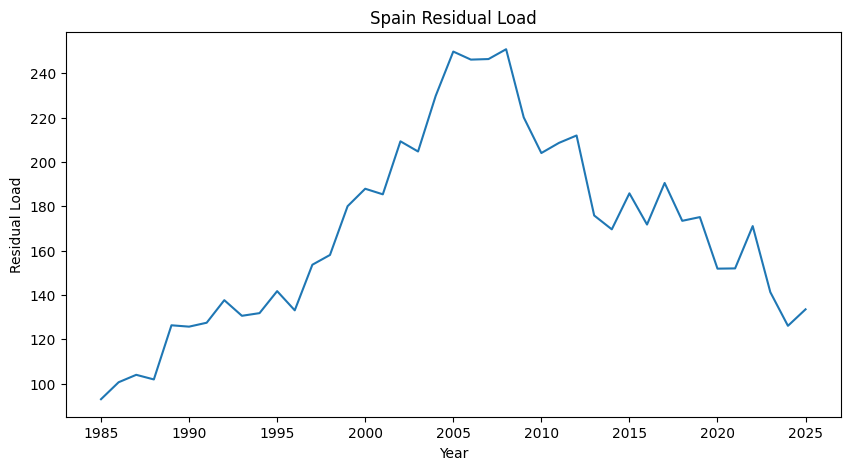

In [9]:
spain = df_eu[df_eu["Entity"] == "Spain"]

plt.figure(figsize=(10,5))

plt.plot(
    spain["Year"],
    spain["residual_load"]
)

plt.title("Spain Residual Load")
plt.xlabel("Year")
plt.ylabel("Residual Load")

plt.show()